In [2]:
import importlib
lunar_neutrino_lib = importlib.import_module("lunar_neutrino_lib")
importlib.reload(lunar_neutrino_lib)
from lunar_neutrino_lib import *


In [3]:
def visualize_oscillation(three_flavor_prob_output):
    plt.plot(three_flavor_prob_output[0], three_flavor_prob_output[1], label=r'$P_e$')   
    plt.plot(three_flavor_prob_output[0], three_flavor_prob_output[2], label=r'$P_{\mu}$')
    plt.plot(three_flavor_prob_output[0], three_flavor_prob_output[3], label=r'$P_{\tau}$')
    plt.legend(loc='best')
    plt.xlabel('L (km)')
    plt.ylabel('Probability')
    return

In [4]:
def find_dominant_oscillation(energy):
    radius = 400
    ratio = 1
    density_function = make_density_function_from_ratio(ratio, radius)
    after_moon = three_flavor_prob_any_moon_density(energy, 0, 0, density_function)  #assume it goes through the middle of the moon
    visualize_oscillation(after_moon) 
    

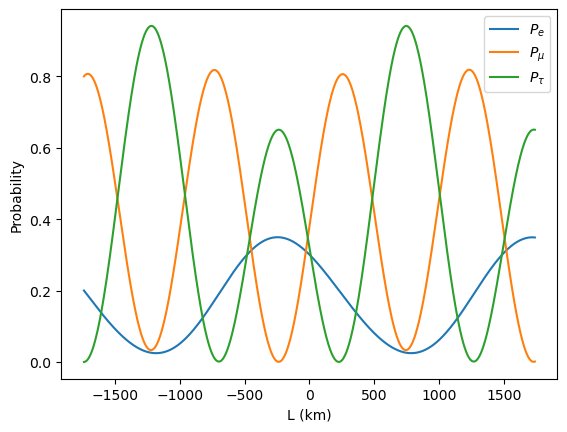

In [10]:
find_dominant_oscillation(1)

In [2]:
def plot_oscillation_through_moon(energy):
    radius = 400
    ratios = [1, 4, 10]
    
    for ratio in ratios:   
        density_function = make_density_function_from_ratio(ratio, radius)
        after_moon = three_flavor_prob_any_moon_density(energy, 0, 0, density_function) #assume it goes through the middle of the moon
        plt.plot(after_moon[0], after_moon[2], label=("ratio=" +str(ratio)))
    
    plt.legend(loc='best')
    plt.xlabel('L (km)')
    plt.ylabel('Muon Probability')
    plt.title("Muon Probability by ratios (radius=400km)")
    plt.savefig("Muon_Probability_by_ratios_energy_" + str(energy) + ".png")

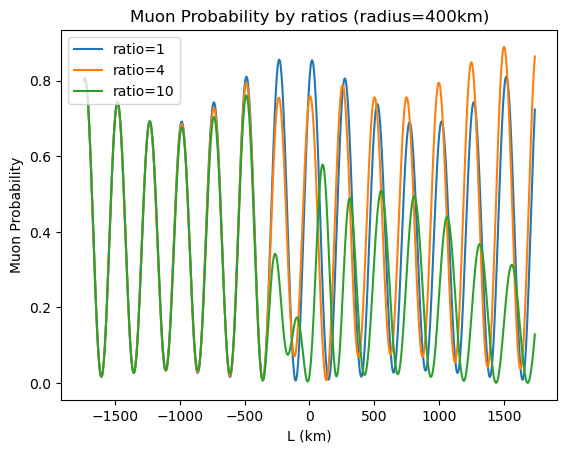

In [6]:
plot_oscillation_through_moon(0.25)

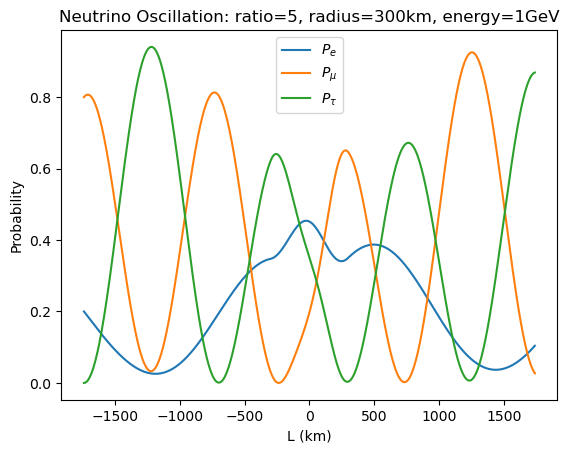

In [25]:
plot_oscillation_through_moon(1, 5, 300)

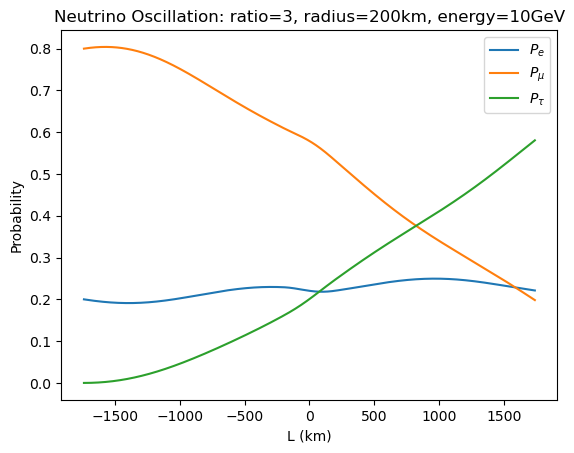

In [17]:
plot_oscillation_through_moon(10, 3, 200)

In [41]:
def plot_oscillation_through_moon(energy):
    radii = [200, 400, 600]
    ratio = 4

    for radius in radii:
        density_function = make_density_function_from_ratio(ratio, radius)
        after_moon = three_flavor_prob_any_moon_density(energy, 0, 0,
                                                        density_function)  #assume it goes through the middle of the moon
        plt.plot(after_moon[0], after_moon[2], label=("radius=" + str(radius)))

    plt.legend(loc='best')
    plt.xlabel('L (km)')
    plt.ylabel('Muon Probability')
    plt.title("Muon Probability by radii (ratio=4)")
    plt.savefig("Muon_Probability_by_radius_energy_" + str(energy) + ".png")


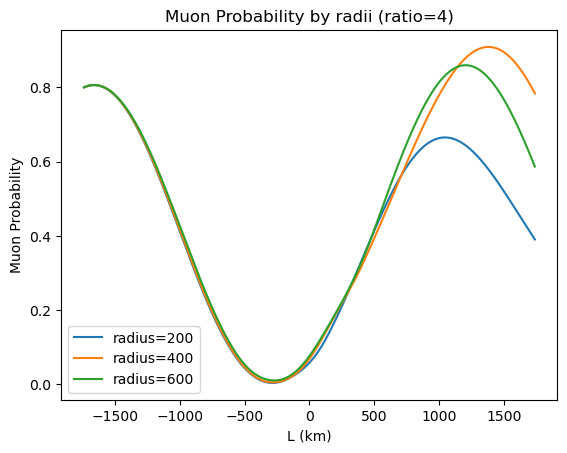

In [47]:
plot_oscillation_through_moon(3)

In [ ]:
def plot_oscillation_through_moon_many_radii(energy):  #energy in GeVs
    radius = 400
    ratios = [1, 4, 10]
    r_moon = 1737 #km

    for ratio in ratios:
        radii = np.linspace(0,r_moon,50)
        for radius in radii:
            density_function = make_density_function_from_ratio(ratio, radius)
            after_moon = three_flavor_prob_any_moon_density(energy, 0, 0,
                                                            density_function)  #assume it goes through the middle of the moon
        plt.plot(after_moon[0], after_moon[2], label=("ratio=" + str(ratio)))

    plt.legend(loc='best')
    plt.xlabel('L (km)')
    plt.ylabel('Muon Probability')
    plt.title("Muon Probability by ratios (radius=400km)")
    plt.savefig("Muon_Probability_by_ratios_energy_" + str(energy) + ".png")

In [3]:
#this function simulates many neutrinos of a given energy hitting the moon at different locations and travelling through the earth
#then it returns the three flavor probabilities
def without_earth_monte_carlo_uniform_core(energy, core_mantle_density_ratio, core_radius):  #energy in GeVs
    r_moon = 1737  #km

    density_function = make_density_function_from_ratio(core_mantle_density_ratio, core_radius)

    e_prob = 0
    m_prob = 0
    t_prob = 0
    scale_factor = 0

    radii = np.linspace(0, r_moon, 50)
    for radius in radii:
        after_moon = three_flavor_prob_any_moon_density(energy, radius, 0, density_function)
        e_prob += after_moon[1][-1] * radius
        m_prob += after_moon[2][-1] * radius
        t_prob += after_moon[3][-1] * radius
        scale_factor += radius

    #normalize probabilities
    e_prob /= scale_factor
    m_prob /= scale_factor
    t_prob /= scale_factor

    return m_prob

In [26]:
def plot_moon_final_probabilities_vs_radii(energy):
    radii = np.linspace(100, 400, 50)
    ratios = [1, 4, 10]
    
    
    for ratio in ratios:
        m_probs = []
        for radius in radii:
            m_prob = without_earth_monte_carlo_uniform_core(energy, ratio, radius)
            m_probs.append(m_prob)
            
        plt.plot(radii, m_probs, label=("ratio=" + str(ratio)))
        

    plt.legend(loc='best')
    plt.xlabel('Core Radius (km)')
    plt.ylabel('Muon Probability')
    plt.title("Muon Probability vs Radii (for a few ratios) ")
    plt.savefig("Muon_Probability_vs_radius" + str(energy) + ".png")


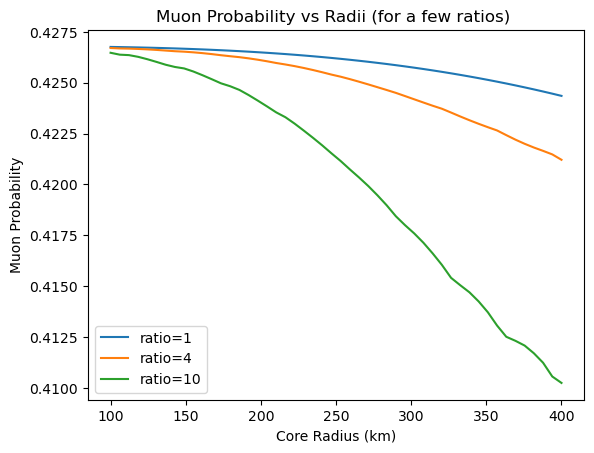

In [27]:
plot_moon_final_probabilities_vs_radii(1)

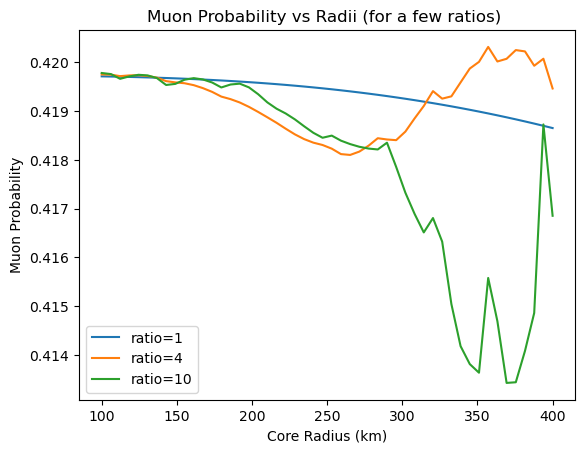

In [28]:
plot_moon_final_probabilities_vs_radii(0.1)

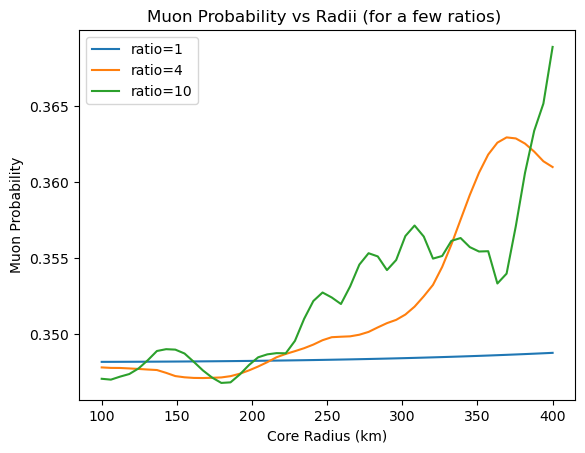

In [29]:
plot_moon_final_probabilities_vs_radii(0.01)

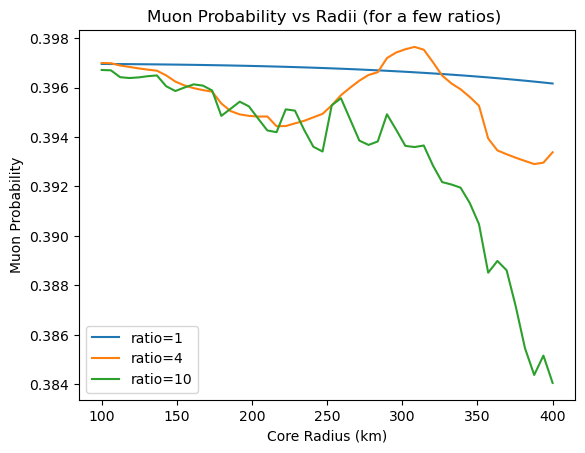

In [30]:
plot_moon_final_probabilities_vs_radii(0.05)


In [34]:
def plot_moon_final_probabilities_vs_ratios(energy):
    ratios = np.linspace(1, 15, 50)
    radii = [200, 400, 500]
    
    
    for radius in radii:
        m_probs = []
        for ratio in ratios:
            m_prob = without_earth_monte_carlo_uniform_core(energy, ratio, radius)
            m_probs.append(m_prob)
            
        plt.plot(ratios, m_probs, label=("radius=" + str(radius)) + " km")
        

    plt.legend(loc='best')
    plt.xlabel('Core-Mantle Densty ratio)')
    plt.ylabel('Muon Probability')
    plt.title("Muon Probability vs Ratio (for a few radii) ")
    plt.savefig("Muon_Probability_vs_ratio_energy_" + str(energy) + ".png")
    

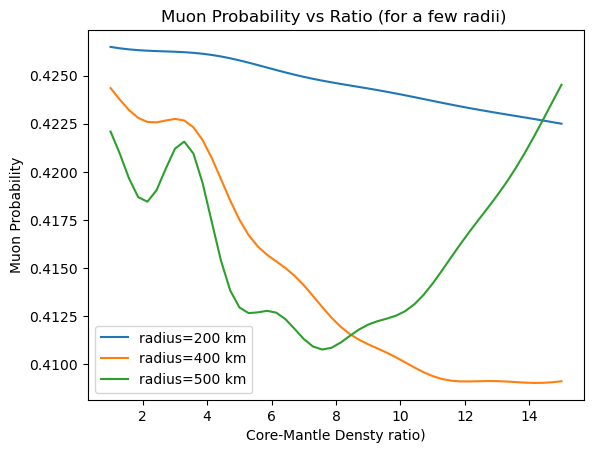

In [35]:
plot_moon_final_probabilities_vs_ratios(1)

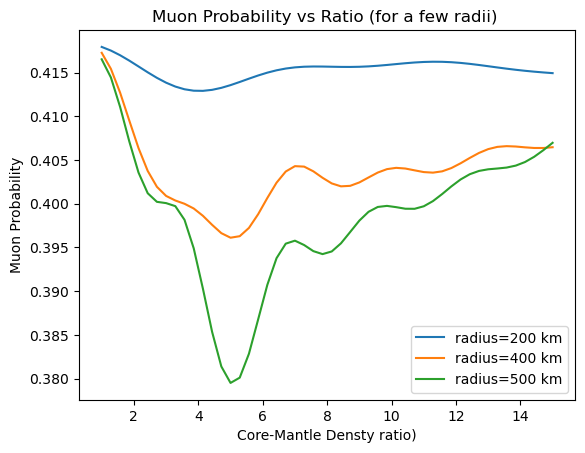

In [36]:
plot_moon_final_probabilities_vs_ratios(0.5)

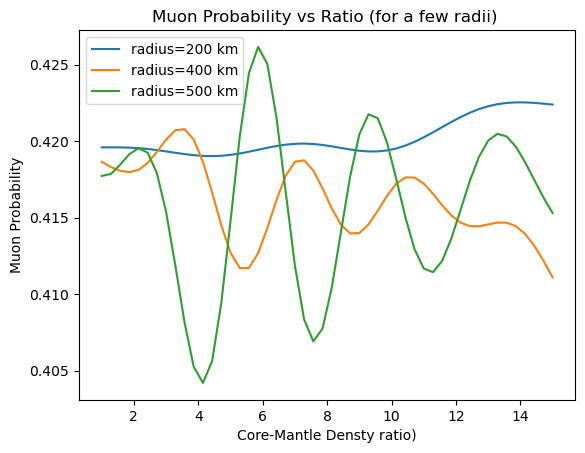

In [37]:
plot_moon_final_probabilities_vs_ratios(0.1)

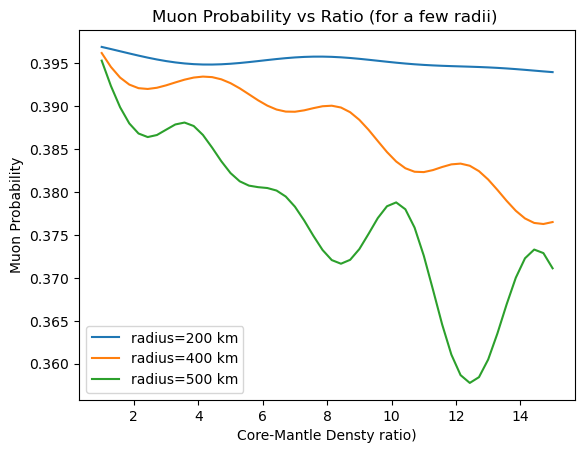

In [38]:
plot_moon_final_probabilities_vs_ratios(0.05)

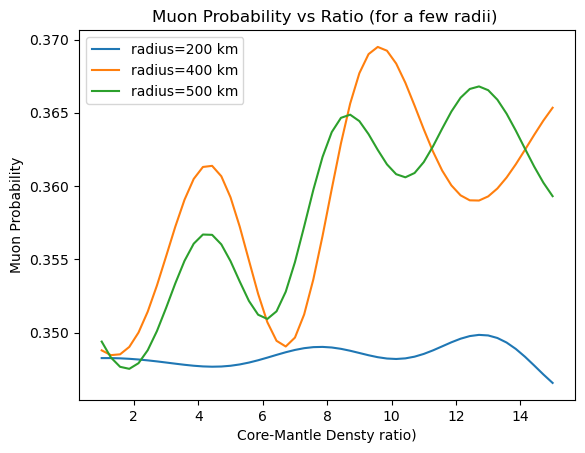

In [39]:
plot_moon_final_probabilities_vs_ratios(0.01)